# Multiple Type Experiment

In [1]:
import warnings;
warnings.filterwarnings('ignore');

from time import sleep
from tqdm.auto import tqdm

import sys
import importlib
import numpy as np
import nbformat
# import plotly.express
# import plotly.express as px
import pandas as pd
import cvxpy as cp
import scipy.optimize as optimization
import matplotlib.pyplot as plt
import seaborn as sns

### Confidence Scaling

In [21]:
cup = 1
clow = 3

### CVXPY Code

In [3]:
def generate_cvxpy_solve(num_types, num_resources):
    x = cp.Variable(shape=(num_types,num_resources))

    sizes = cp.Parameter(num_types, nonneg=True)
    weights = cp.Parameter((num_types, num_resources), nonneg=True)
    budget = cp.Parameter(num_resources, nonneg=True)


    objective = cp.Maximize(cp.log(cp.sum(cp.multiply(x, weights), axis=1)) @ sizes)


    constraints = []
    constraints += [0 <= x]
    for i in range(num_resources):
        constraints += [x[:, i] @ sizes <= budget[i]]
    # constraints += [x @ sizes <= budget]

    prob = cp.Problem(objective, constraints)
    
    def solver(true_sizes, true_weights, true_budget):
        sizes.value = true_sizes
        weights.value = true_weights
        budget.value = true_budget
        
        prob.solve()
        
        return prob.value, np.around(x.value, 5)
    
    return prob, solver

### Simple Test

In [4]:
prob, solver = generate_cvxpy_solve(2, 2)

solver(np.asarray([1., 1.]), np.asarray([[1,1],[1,1]]), np.asarray([1,1]))

(2.9030394753597835e-10, array([[0.5, 0.5],
        [0.5, 0.5]]))

In [5]:
prob, solver = generate_cvxpy_solve(5,3)

### Sensitivity of EG Program

Calculating difference in allocations for: 0.5
Sizes: ([2.0, 3.0], [1.5, 2.5], [2.5, 3.5])
Solutions: 
Orig: [[1.    0.   ]
 [0.    0.667]]
Minus Delta: [[1.333 0.   ]
 [0.    0.8  ]]
Plus Delta: [[0.8   0.   ]
 [0.    0.571]]
Objective Values: (1.840759378277478, 2.4054081196928085, 1.0660513805236598)
Testing Budget Constraint: 
[ True  True]
Testing Monotonicity:
[[ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]]
Calculating difference in allocations for: 0.2
Sizes: ([2.0, 3.0], [1.8, 2.8], [2.2, 3.2])
Solutions: 
Orig: [[1.    0.   ]
 [0.    0.667]]
Minus Delta: [[1.111 0.   ]
 [0.    0.714]]
Plus Delta: [[0.909 0.   ]
 [0.    0.625]]
Objective Values: (1.840759378277478, 2.0945170601026097, 1.553625026541286)
Testing Budget Constraint: 
[ True  True]
Testing Monotonicity:
[[ True  True]
 [ True  True]]
[[ True  True]
 [ True  True]]
Calculating difference in allocations for: 0.1
Sizes: ([2.0, 3.0], [1.9, 2.9], [2.1, 3.1])
Solutions: 
Orig: [[1.    0.   ]
 [0.    0.667]]

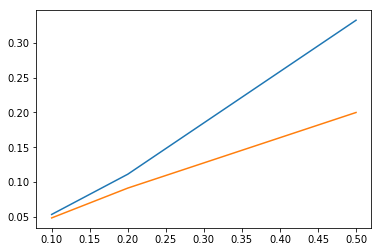

In [27]:
eps = 0.05

delta_list = [.5, .2, .1]
y1 = np.zeros(len(delta_list))
y2 = np.zeros(len(delta_list))

prob, solver = generate_cvxpy_solve(2, 2)
true_weights = np.asarray([[1.1, .4],[1.3, 2.6]])
true_budget = [2., 2.]


index = 0
for delta in delta_list:
    print('Calculating difference in allocations for: ' + str(delta))
    sizes_1 = [2., 3.]
    sizes_2 = [2-delta, 3-delta]
    sizes_3 = [2+delta, 3+delta]
    
    print('Sizes: ' + str((sizes_1, sizes_2, sizes_3)))
          
    v1, x_1 = solver(sizes_1, true_weights, true_budget)
    v2, x_2 = solver(sizes_2, true_weights, true_budget)
    v3, x_3 = solver(sizes_3, true_weights, true_budget)
    
    x_1 = np.around(x_1, 3)
    x_2 = np.around(x_2, 3)
    x_3 = np.around(x_3, 3)
    
    print('Solutions: ')
    print('Orig: ' + str(x_1))
    print('Minus Delta: ' + str(x_2))
    print('Plus Delta: ' + str(x_3))
    print('Objective Values: ' + str((v1, v2, v3)))
    
    print('Testing Budget Constraint: ')
    print(np.around(sizes_1 @ x_1,1) <= np.around(true_budget,1))
    
    print('Testing Monotonicity:')
    print(x_1 <= x_2)
    print(x_1 >= x_3)
    y1[index] = np.max(np.abs(x_1 - x_2))
    y2[index] = np.max(np.abs(x_1 - x_3))
    index += 1
    
print(delta_list, y1, y2)
plt.plot(delta_list, y1)
plt.plot(delta_list, y2)

### Offline Optimal Solution

In [9]:
def offline_opt(budget, size, mean, weights, solver):
    tot_size = np.sum(size, axis=0)
    _, x = solver(tot_size, weights, budget)
    allocation = np.zeros((size.shape[0], weights.shape[0], weights.shape[1]))
    for i in range(size.shape[0]):
        allocation[i,:,:] = x
    return allocation

### Threshold Based Algorithms

In [19]:
def fixed_threshold(budget, size, mean, weights, solver):
    
    num_locations = size.shape[0]
    num_types = weights.shape[0]
    num_resources = weights.shape[1]
    
    allocation = np.zeros((n, num_types, num_resources))
    budget_remaining = budget


#     tot_mean_size = size[0] + np.sum(mean[1:], axis=0) + clow*np.sqrt(num_locations * np.log(num_locations))
    
    tot_mean_size = (size[0] + np.sum(mean[1:], axis=0))*(1 + clow*np.sqrt(num_locations * np.log(num_locations)) / (size[0] + np.min(np.sum(mean[1:], axis=0))))
    print('True Size: ' + str(np.sum(size, axis=0)))
    print('Estimated Size: ' + str(tot_mean_size))
    
    
    # np.sum(mean)(1 + (sqrt / min(sum(mean)))
    
    _, lower_thresh = solver(tot_mean_size, weights, budget)


    for i in range(n):

        if np.min(budget_remaining - np.matmul(size[i,:], lower_thresh)) > 0:
            allocation[i,:,:] = lower_thresh
        else:
            print('Fixed: Out of budget!')
            allocation[i, :, :] = np.array([budget_remaining / np.sum(size[i,:]),]*num_types)

        budget_remaining -= np.matmul(size[i, :], allocation[i])
    
    
    return allocation, budget_remaining

In [12]:
def adapt_init_threshold(budget, size, mean, weights, solver):
    
    num_locations = size.shape[0]
    num_types = weights.shape[0]
    num_resources = weights.shape[1]
    
    allocation = np.zeros((n, num_types, num_resources))
    budget_remaining = budget


    tot_low_mean_size = size[0] + np.sum(mean[1:], axis=0) + clow *np.sqrt(num_locations * np.log(num_locations))
    tot_up_mean_size = np.maximum(1, size[0] + np.sum(mean[1:], axis=0) - cup *np.sqrt(num_locations * np.log(num_locations)))
    _, lower_thresh = solver(tot_low_mean_size, weights, budget)
    _, upper_thresh = solver(tot_up_mean_size, weights, budget)


    for i in range(n):
        rem = n - i
        budget_required = budget_remaining - np.matmul(size[i, :], upper_thresh) - np.matmul(np.sum(mean[(i+1):], axis=0) + clow*np.sqrt(rem*np.log(rem)), lower_thresh)

        if np.min(budget_remaining - np.matmul(size[i,:], upper_thresh)) > 0 and np.min(budget_required) > 0:
            # print('Allocating upper threshold')
            allocation[i,:,:] = upper_thresh
        elif np.min(budget_remaining - np.matmul(size[i,:], lower_thresh)) > 0:
            allocation[i,:,:] = lower_thresh
        else:
            print('Adapt: Out of budget!')
            allocation[i, :, :] = np.array([budget_remaining / np.sum(size[i,:]),]*num_types)

        budget_remaining -= np.matmul(size[i, :], allocation[i])
    
    return allocation, budget_remaining

### Scaling with n

In [13]:
#np.random.choice(size=5, a=[1.,2.], p=[1/2, 1/2])
1+np.random.poisson(size=5,lam = 1.5)

array([1, 3, 4, 3, 1])

In [23]:
data = []
num_types = 5
num_resources = 3
weights = np.asarray([[1, 2, 3], [1, 3, 2], [4, 1, 5], [1, 2, .5], [3, 7, 5]])

# algo_list = [adapt_init_threshold_new_cb, adapt_threshold, adapt_init_threshold, sid_threshold, adapt_init_under_over_threshold, fixed_threshold]
algo_list = [fixed_threshold,adapt_init_threshold]

num_iterations = 5
max_n = 100

mean_size = np.asarray([1, 3, 6, 2, 5])
# dist_weights = [1/5, 1/5, 1/5, 1/5, 1/5]

for n in tqdm(np.arange(2,max_n+1)):
    print('Num Locations: ' + str(n))
    # pected_size = mean_size
    budget = [n, n, n]
    
    mean = np.array([mean_size,]*n)
    # print(mean)
    for i in range(num_iterations):
        # size = np.random.choice(size=(n, num_types), a=[1.,2.], p=[1/2, 1/2])
        size = 1+np.random.poisson(size=(n, num_types), lam = mean_size)
        # print('Size: ' + str(size))
        total_num_types = np.sum(size, axis=0)
        
        prob, solver = generate_cvxpy_solve(num_types, num_resources)

        
        # print(num_types, num_resources, budget.shape size.shape, )
        
        opt = offline_opt(budget, size, mean, weights, solver)
        
        # print('opt: ' + str(opt))
        for algo in algo_list:
            sol, waste = algo(budget, size, mean, weights, solver)
            
            # print('Algo: ' + str(sol))
            # print('Opt: ' + str(opt))
            
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'L1', 'Value': np.sum(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Linf', 'Value': np.max(np.abs(opt-sol))}
            data.append(data_dict)
            data_dict = {'NumGroups': n, 'Algorithm':algo.__name__, 'Norm': 'Waste', 'Value': np.max(waste)}
            data.append(data_dict)
        
    sleep(0)

  0%|          | 0/99 [00:00<?, ?it/s]

Num Locations: 2
True Size: [ 4 10 13  8  8]
Estimated Size: [ 4.17741002  8.64837403 13.15858504  7.41289203 11.11933804]
Fixed: Out of budget!
True Size: [ 4  7 20  7 11]
Estimated Size: [ 5.17741002  8.64837403 16.76611503  5.56988003 11.96235004]
Fixed: Out of budget!
Adapt: Out of budget!
True Size: [ 4  4 12  7 12]
Estimated Size: [ 3.17741002  6.96235004 14.91329129  6.47176253 13.76611503]
True Size: [ 3  8 18  8 11]
Estimated Size: [ 3.17741002  9.56988003 18.66799753  6.47176253 11.96235004]
True Size: [ 2 10 15  9 10]
Estimated Size: [ 3.17741002 11.47176253 18.66799753  7.41289203 11.11933804]
Num Locations: 3
True Size: [ 5 13 22  8 17]
Estimated Size: [ 4.81544399 13.02573998 24.46584761  9.54162158 19.63088797]
True Size: [ 8 16 19  7 28]
Estimated Size: [ 6.81544399 16.54162158 22.08474897  9.54162158 25.78368078]
Fixed: Out of budget!
True Size: [ 5 10 29  8 21]
Estimated Size: [ 5.81544399 11.63088797 24.46584761  8.72316598 20.42917197]
Fixed: Out of budget!
Adapt: O

True Size: [ 26  63 119  51 110]
Estimated Size: [ 22.37344122  62.28768312 118.96264479  42.62215752 101.24480407]
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Num Locations: 16
True Size: [ 40  81 117  45 104]
Estimated Size: [ 24.66043689  67.74285083 126.87323561  46.65576456 108.46140775]
Fixed: Out of budget!
True Size: [ 30  59 104  50  81]
Estimated Size: [ 24.66043689  65.76116504 126.37925283  46.65576456 106.69339549]
True Size: [ 31  69 111  52 102]
Estimated Size: [ 22.66043689  65.76116504 126.63707522  45.21080096 106.69339549]
Fixed: Out of budget!
Adapt: Out of budget!
True Size: [ 29  70 123  45 100]
Estimated Size: [ 22.66043689  66.65109222 126.64174756  44.53729297 106.69339549]
Fixed: Out of budget!
Adapt: Out of budget!
True Size: [ 40  60  98  50 100]
Estimated Size: [ 22.66043689  66.17691619 126.95163514  45.21080096 106.86189319]
Fixed: Out of budget!
Adapt: Out of budget!
Num Locations: 17
True Size: [ 40  78 118  54  98]
Estimated Size:

True Size: [ 53  94 181  72 141]
Estimated Size: [ 38.43332367 107.78441802 211.23089783  71.51726497 176.09162558]
True Size: [ 54 126 202  88 186]
Estimated Size: [ 38.43332367 109.86075986 210.31105955  74.34514351 176.94861181]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
True Size: [ 52  97 184  79 161]
Estimated Size: [ 38.43332367 107.78441802 209.75620106  72.89078626 176.16258613]
True Size: [ 54  94 188  76 156]
Estimated Size: [ 36.43332367 108.25696336 209.59490174  73.60887084 176.09162558]
Fixed: Out of budget!
True Size: [ 52 102 177  77 131]
Estimated Size: [ 37.43332367 108.25696336 211.23089783  73.60887084 176.28819605]
Num Locations: 28
True Size: [ 54 114 206  98 149]
Estimated Size: [ 38.65928187 111.95932003 217.01231283  76.80930095 182.25935819]
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
True Size: [ 47 128 198  93 169]
Estimated S

True Size: [ 76 148 243 115 208]
Estimated Size: [ 47.35811084 140.28094659 275.83785221  96.29645782 231.14190394]
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
True Size: [ 66 141 241 123 204]
Estimated Size: [ 47.35811084 142.28829557 275.68357266  94.81952871 231.69445566]
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
True Size: [ 79 148 237 111 211]
Estimated Size: [ 47.35811084 140.74446362 275.5324153   95.55128723 231.11149877]
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Num Locations: 37
True Size: [ 77 136 246 110 216]
Estimated Size: [ 48.55871804 146.47298393 282.84438276  97.22830393 237.38724981]
Fixed: Out of budget!
True Size: [ 77 142 263 118 228]
Estimated Size: [ 50.55871804 143.05135856 282.78848429  97.96156428 237.38724981]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
True Size: [ 72 138 266 112 216]
Estimated Size: [ 49.55871804 144.36441052 282.9039107   96.5

...

Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Num Locations: 88
True Size: [173 363 584 256 497]
Estimated Size: [107.8495753  322.22542089 640.73490779 216.8266418  534.93275144]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
True Size: [174 369 646 268 540]
Estimated Size: [110.8495753  322.22542089 640.7066525  215.25309273 535.80428577]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Ad

Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
True Size: [198 346 641 262 542]
Estimated Size: [112.26050876 332.47439667 661.29345713 221.29837456 552.68686746]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adap

Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
True Size: [194 378 661 275 535]
Estimated Size: [115.66566499 342.12686171 681.80956817 229.68552795 569.11084231]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
True Size: [180 365 651 280 588]
Estimated Size: [114.66566499 343.88825365 681.8767848  228.11148248 570.585159  ]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget

True Size: [208 376 702 276 588]
Estimated Size: [120.06530239 352.33609892 702.36382762 235.70070066 586.36997023]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
True Size: [212 369 647 323 586]
Estimated Size: [120.06530239 352.91922219 702.19613718 237.28799269 586.36997023]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget

True Size: [190 409 711 279 611]
Estimated Size: [121.45966026 362.52909325 722.73565868 241.70472392 604.14508123]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
True Size: [193 387 712 281 593]
Estimated Size: [123.45966026 363.11664783 722.81643647 242.49437676 602.96476186]
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Fixed: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget!
Adapt: Out of budget

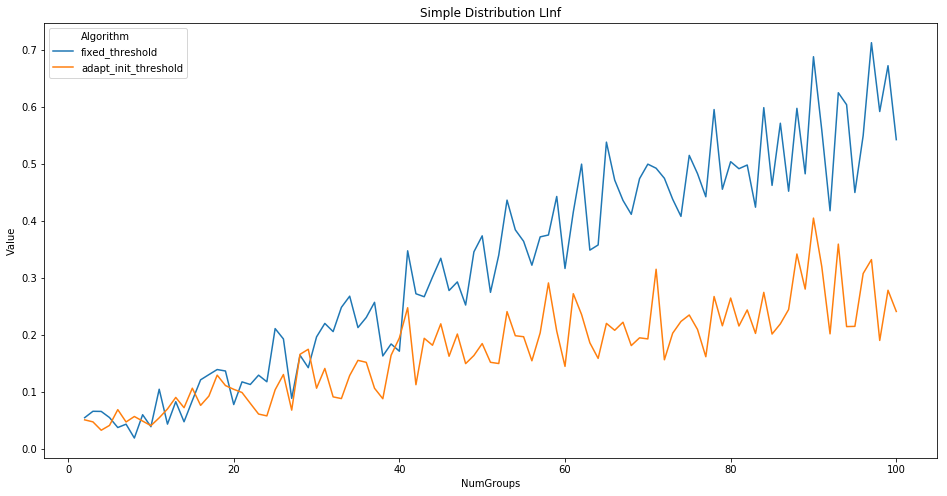

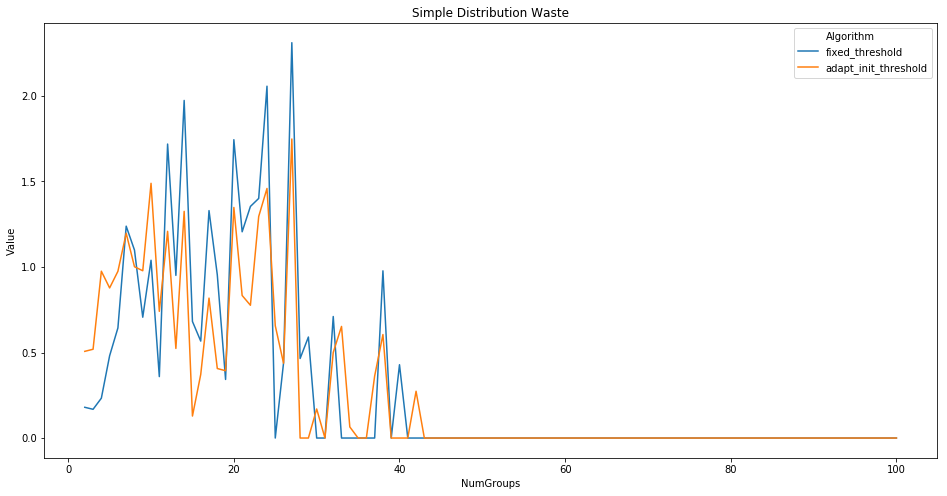

In [24]:
df = pd.DataFrame.from_records(data)
df.columns


#filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
#plt.figure(figsize=(20,10))
#plt.title('Simple Distribution L1')
#sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'])

filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution LInf')
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', data=df[df.Norm == 'Linf'], ci=None)


filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(16,8))
plt.title('Simple Distribution Waste')
sns.lineplot(x='NumGroups', y='Value', hue='Algorithm', data=df[df.Norm == 'Waste'], ci=None)


### Group by Group Difference

In [13]:
data = []
num_types = 5
num_resources = 3
weights = np.asarray([[1, 2, 3], [1, 3, 2], [4, 1, 5], [1, 2, .5], [3, 7, 5]])

# algo_list = [adapt_init_threshold_new_cb, adapt_threshold, adapt_init_threshold, sid_threshold, adapt_init_under_over_threshold, fixed_threshold]
algo_list = [fixed_threshold,adapt_init_threshold]

num_iterations = 20
n = 100

mean_size = np.asarray([1, 3, 6, 2, 5])



for i in tqdm(range(num_iterations)):
    budget = [n, n, n]
    
    mean = np.array([mean_size,]*n)
    # print(mean)

    # size = np.random.choice(size=n, a=[1.,2.], p=[1/2, 1/2])
    size = 1+np.random.poisson(size=(n, num_types), lam = mean_size)
    # print('Size: ' + str(size))
    total_num_types = np.sum(size, axis=0)

    prob, solver = generate_cvxpy_solve(num_types, num_resources)


    # print(num_types, num_resources, budget.shape size.shape, )

    opt = offline_opt(budget, size, mean, weights, solver)

    # print('opt: ' + str(opt))
    for algo in algo_list:
        sol, waste = algo(budget, size, mean, weights, solver)

        for i in range(n):
            data.append({'Location':i, 'Algorithm':algo.__name__, 'Value': np.max(opt[i] - sol[i])})
            
for i in range(n):
    data.append({'Location': i, 'Algorithm':'Zero', 'Value': 0})

  0%|          | 0/20 [00:00<?, ?it/s]

[]

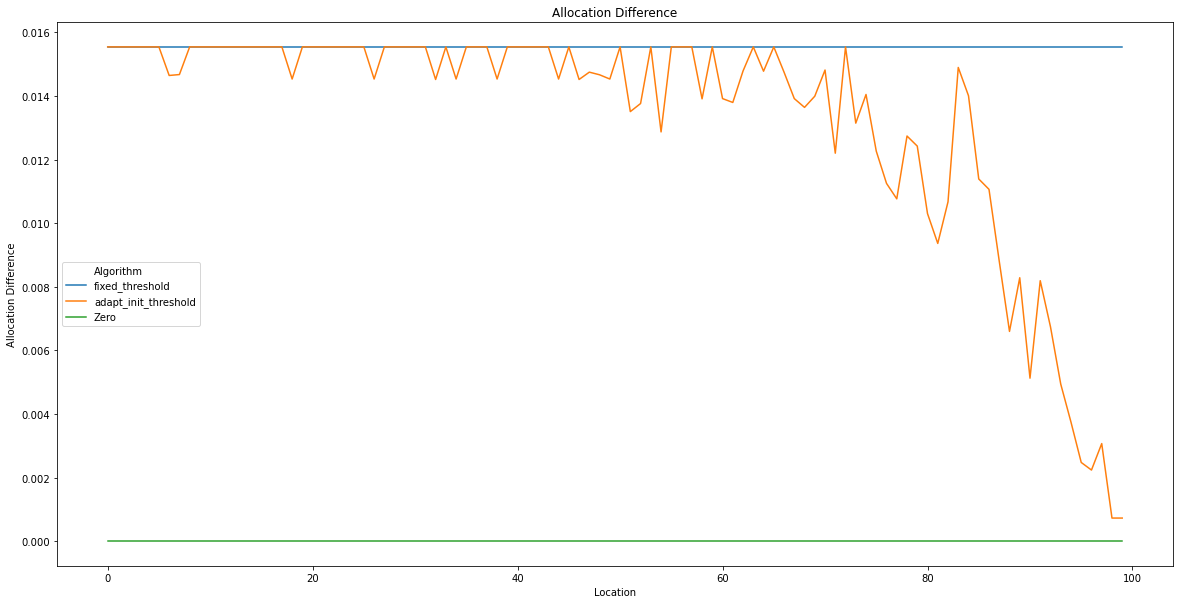

In [14]:
df = pd.DataFrame.from_records(data)

plt.figure(figsize=(20,10))
sns.lineplot(x='Location', y='Value', hue = 'Algorithm', data=df, ci = None)
plt.title('Allocation Difference')
plt.xlabel('Location')
plt.ylabel('Allocation Difference')
plt.plot()

Note: Discrepancy is between where max and average are between this plot and the other one.